In [2]:
# ============================================
# CONFIGURATION - Modifiez ces valeurs ici
# ============================================

NB_VILLES = 10              # Nombre de villes (incluant le dépôt)
TAILLE_GRILLE = 100         # Taille de la grille (coordonnées de 0 à TAILLE_GRILLE)
PROBA_PERTURBATION = 0.3    # Probabilité de perturbation (bouchon ou route bloquée)

# Paramètres du Recuit Simulé
T_INITIAL = 10000           # Température initiale
T_FINAL = 0.1               # Température finale
ALPHA = 0.99                # Facteur de refroidissement
ITER_PAR_PALIER = 100       # Itérations par palier de température

In [3]:
import random
import math

def generer_instance_realiste(nb_villes, taille_grille, proba_perturbation):
    # 1. Génération des coordonnées
    coordonnees = {i: (random.randint(0, taille_grille), random.randint(0, taille_grille)) 
                   for i in range(nb_villes)}
    
    # 2. Tournée Fantôme
    villes_a_visiter = list(range(1, nb_villes))
    random.shuffle(villes_a_visiter)
    tournee_fantome = [0] + villes_a_visiter + [0]
    
    # 3. Calcul des distances (SANS NUMPY, avec listes natives)
    matrice_temps = [[0] * nb_villes for _ in range(nb_villes)]
    for i in range(nb_villes):
        for j in range(nb_villes):
            if i != j:
                xi, yi = coordonnees[i]
                xj, yj = coordonnees[j]
                matrice_temps[i][j] = math.ceil(math.hypot(xj - xi, yj - yi))
                
    # 4. CONTRAINTE 2 : Perturbations
    arret_fantome_set = set(zip(tournee_fantome[:-1], tournee_fantome[1:]))
    for i in range(nb_villes):
        for j in range(nb_villes):
            if i != j:
                if (i, j) not in arret_fantome_set and random.random() < proba_perturbation:
                    type_perturbation = random.choice(["bouchon", "bloquee"])
                    if type_perturbation == "bouchon":
                        matrice_temps[i][j] = int(matrice_temps[i][j] * random.uniform(1.5, 3.0))
                    elif type_perturbation == "bloquee":
                        matrice_temps[i][j] = 999999
                        
    # 5. CONTRAINTE 1 : Fenêtres de temps
    fenetres_temps = {0: (0, 999999)}
    temps_actuel = 0
    
    for index in range(len(tournee_fantome) - 1):
        ville_depart = tournee_fantome[index]
        ville_arrivee = tournee_fantome[index + 1]
        temps_actuel += matrice_temps[ville_depart][ville_arrivee]
        
        if ville_arrivee != 0:
            marge_avant = random.randint(0, 20)
            marge_apres = random.randint(10, 50)
            ouverture = max(0, temps_actuel - marge_avant)
            fermeture = temps_actuel + marge_apres
            fenetres_temps[ville_arrivee] = (ouverture, fermeture)
            
    instance = {
        "coordonnees": coordonnees,
        "matrice_temps": matrice_temps,
        "fenetres_temps": fenetres_temps,
        "solution_garantie": tournee_fantome
    }
    return instance

# Génération de l'instance avec les paramètres de configuration
data = generer_instance_realiste(NB_VILLES, TAILLE_GRILLE, PROBA_PERTURBATION)
print("Coordonnées :", data["coordonnees"])
print("\nFenêtres de temps :", data["fenetres_temps"])
print("\nTournée réalisable garantie :", data["solution_garantie"])

Coordonnées : {0: (3, 45), 1: (14, 26), 2: (13, 47), 3: (3, 5), 4: (88, 80), 5: (61, 32), 6: (25, 96), 7: (26, 69), 8: (94, 31), 9: (80, 60)}

Fenêtres de temps : {0: (0, 999999), 9: (60, 89), 5: (103, 123), 1: (155, 179), 6: (221, 282), 7: (255, 270), 8: (328, 380), 3: (423, 482), 4: (532, 581), 2: (611, 679)}

Tournée réalisable garantie : [0, 9, 5, 1, 6, 7, 8, 3, 4, 2, 0]


1. La fonction d'évaluation (Le juge)
Avant de chercher des solutions, l'algorithme doit pouvoir "noter" une tournée. C'est ici que l'on gère tes deux contraintes.

Si le camion arrive trop tôt, il doit attendre (le temps tourne, c'est naturel). S'il arrive en retard ou prend une route bloquée, au lieu de faire "planter" le programme, on lui ajoute une pénalité gigantesque. L'algorithme comprendra très vite qu'il faut fuir ces solutions.

In [4]:
def evaluer_tournee(tournee_interne, instance):
    """
    Calcule le coût total d'une tournée.
    Note : 'tournee_interne' ne contient pas le dépôt de départ et d'arrivée.
    """
    matrice = instance["matrice_temps"]
    fenetres = instance["fenetres_temps"]
    
    # On rajoute le dépôt (0) au début et à la fin
    tournee = [0] + tournee_interne + [0]
    temps_actuel = 0
    penalite = 0
    
    for i in range(len(tournee) - 1):
        ville_dep = tournee[i]
        ville_arr = tournee[i+1]
        
        # 1. Ajout du temps de trajet
        temps_trajet = matrice[ville_dep][ville_arr]
        
        # CONTRAINTE 2 : Route bloquée ?
        if temps_trajet == 999999:
            penalite += 1000000  # Pénalité colossale
            
        temps_actuel += temps_trajet
        
        # 2. CONTRAINTE 1 : Fenêtres de temps
        ouverture, fermeture = fenetres[ville_arr]
        
        if temps_actuel < ouverture:
            # Arrivé trop tôt : on attend l'ouverture
            temps_actuel = ouverture
        elif temps_actuel > fermeture:
            # Arrivé en retard : pénalité proportionnelle au retard
            penalite += 10000 * (temps_actuel - fermeture)
            
    # Le coût final est le temps total mis + les éventuelles pénalités
    return temps_actuel + penalite

HILL CLIMBING
Meilleure tournée trouvée : [0, 9, 5, 1, 6, 7, 8, 3, 4, 2, 0]
Coût total (temps + pénalités) : 640


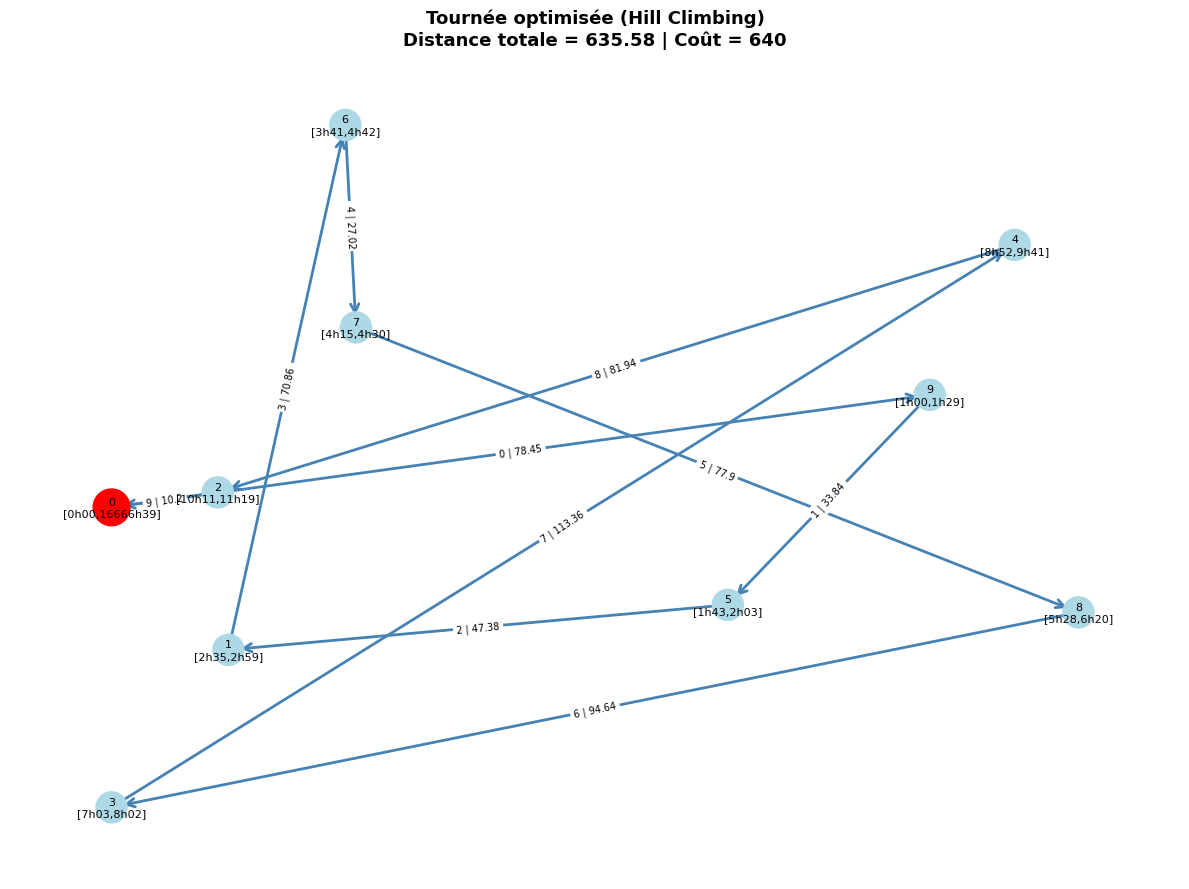

In [5]:
def hill_climbing(instance, max_iter=1000):
    """
    Optimisation par Hill Climbing (échange de deux villes).

    Args:
        instance  : dictionnaire de l'instance (utilise instance["fenetres_temps"]).
        max_iter  : nombre maximal d'itérations sans amélioration.

    Returns:
        tournee   : liste [0, v1, …, vn, 0] (avec dépôts).
        cout      : coût final.
        historique: liste des meilleurs coûts à chaque amélioration.
    """
    import random

    nb_villes        = len(instance["coordonnees"])
    tournee_courante = list(range(1, nb_villes))
    random.shuffle(tournee_courante)
    cout_courant     = evaluer_tournee(tournee_courante, instance)

    historique       = [cout_courant]
    iterations_sans_amelioration = 0

    while iterations_sans_amelioration < max_iter:
        amelioration = False

        # Parcours de tous les échanges 2-opt
        for idx1 in range(len(tournee_courante)):
            for idx2 in range(idx1 + 1, len(tournee_courante)):
                voisin           = list(tournee_courante)
                voisin[idx1], voisin[idx2] = voisin[idx2], voisin[idx1]
                cout_voisin      = evaluer_tournee(voisin, instance)

                if cout_voisin < cout_courant:
                    tournee_courante = voisin
                    cout_courant     = cout_voisin
                    historique.append(cout_courant)
                    amelioration     = True

        if not amelioration:
            iterations_sans_amelioration += 1
        else:
            iterations_sans_amelioration = 0

    tournee_finale = [0] + tournee_courante + [0]
    return tournee_finale, cout_courant, historique

# Lancement du Hill Climbing avec les paramètres de l'instance
print("=" * 60)
print("HILL CLIMBING")
print("=" * 60)
tournee_hc, cout_hc, historique_hc = hill_climbing(data, max_iter=1000)
print(f"Meilleure tournée trouvée : {tournee_hc}")
print(f"Coût total (temps + pénalités) : {cout_hc}")
afficher_graphe(data, tournee_hc, cout=cout_hc)

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

def afficher_graphe(instance, tournee, cout=None, horaires=None):
    G = nx.DiGraph()

    coords = instance["coordonnees"]
    fenetres = horaires if horaires is not None else instance["fenetres_temps"]

    def min_to_h(minutes):
        if isinstance(minutes, (int, float)):
            h = int(minutes // 60)
            m = int(minutes % 60)
            return f"{h}h{m:02d}"
        return str(minutes)

    # Ajouter les noeuds avec positions + infos
    for i, (x, y) in coords.items():
        label = f"{i}"
        if fenetres and i in fenetres:
            ouverture, fermeture = fenetres[i]
            label += f"\n[{min_to_h(ouverture)},{min_to_h(fermeture)}]"

        G.add_node(i, pos=(x, y), label=label)

    # Ajouter les arcs avec poids + ordre
    total_distance = 0
    for i in range(len(tournee) - 1):
        u = tournee[i]
        v = tournee[i + 1]

        x1, y1 = coords[u]
        x2, y2 = coords[v]

        distance = ((x2 - x1)**2 + (y2 - y1)**2) ** 0.5
        total_distance += distance

        G.add_edge(u, v, weight=round(distance, 2), ordre=i)

    pos = nx.get_node_attributes(G, 'pos')
    labels = nx.get_node_attributes(G, 'label')

    plt.figure(figsize=(12, 9))

    # Couleur spéciale pour le dépôt
    node_colors = ["red" if n == 0 else "lightblue" for n in G.nodes()]
    node_sizes  = [700 if n == 0 else 500 for n in G.nodes()]

    # Dessin des noeuds
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors)

    # Dessin des arcs
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=15, edge_color="steelblue", width=2)

    # Labels des noeuds
    nx.draw_networkx_labels(G, pos, labels, font_size=8)

    # Labels des arêtes (ordre | distance)
    edge_labels = {
        (u, v): f"{d['ordre']} | {d['weight']}"
        for u, v, d in G.edges(data=True)
    }
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

    # Titre enrichi
    titre = "Tournée optimisée (Hill Climbing)\n"
    titre += f"Distance totale = {round(total_distance, 2)}"
    if cout is not None:
        titre += f" | Coût = {round(cout, 2)}"

    plt.title(titre, fontsize=13, fontweight="bold")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

2. L'algorithme principal (Le Recuit Simulé)
Voici le cœur de l'optimisation. Il part d'une solution au hasard. À chaque étape, il "secoue" la solution en échangeant l'ordre de deux villes (c'est ce qu'on appelle un voisin).

Si c'est mieux, il garde la solution.

Si c'est pire, il peut la garder quand même pour éviter d'être bloqué, mais cette probabilité diminue au fur et à mesure que la "température" baisse.

In [7]:
def recuit_simule(instance, t_initial=10000, t_final=0.1, alpha=0.99, iter_par_palier=100):
    """
    Algorithme de Recuit Simulé pour le TSP avec Fenêtres de temps.
    """
    nb_villes = len(instance["coordonnees"])
    
    # 1. Génération d'une solution initiale aléatoire
    tournee_courante = list(range(1, nb_villes))
    random.shuffle(tournee_courante)
    cout_courant = evaluer_tournee(tournee_courante, instance)
    
    # On garde la trace de la meilleure solution trouvée depuis le début
    meilleure_tournee = list(tournee_courante)
    meilleur_cout = cout_courant
    
    # Historique pour le graphique de l'étude expérimentale !
    historique_couts = []
    
    temp = t_initial
    
    # 2. Boucle principale de refroidissement
    while temp > t_final:
        for _ in range(iter_par_palier):
            
            # Générer un voisin en échangeant 2 villes au hasard
            voisin = list(tournee_courante)
            idx1, idx2 = random.sample(range(len(voisin)), 2)
            voisin[idx1], voisin[idx2] = voisin[idx2], voisin[idx1]
            
            cout_voisin = evaluer_tournee(voisin, instance)
            
            # 3. Calcul de la différence de coût
            delta = cout_voisin - cout_courant
            
            # 4. Critère d'acceptation
            # Si c'est mieux (delta < 0), ou si la probabilité l'accepte
            if delta < 0 or random.random() < math.exp(-delta / temp):
                tournee_courante = list(voisin)
                cout_courant = cout_voisin
                
                # Mise à jour du meilleur absolu
                if cout_courant < meilleur_cout:
                    meilleure_tournee = list(tournee_courante)
                    meilleur_cout = cout_courant
                    
        # On enregistre le meilleur coût à ce stade pour vos stats
        historique_couts.append(meilleur_cout)
        
        # Baisse de la température
        temp *= alpha
        
    # On rajoute les dépôts pour l'affichage final
    tournee_finale = [0] + meilleure_tournee + [0]
    
    return tournee_finale, meilleur_cout, historique_couts

In [8]:
# Lancement de l'algorithme sur l'instance 'data' générée précédemment
meilleure_tournee, cout_opt, historique = recuit_simule(data, T_INITIAL, T_FINAL, ALPHA, ITER_PAR_PALIER)

print(f"Meilleure tournée trouvée : {meilleure_tournee}")
print(f"Coût total (temps + pénalités) : {cout_opt}")

# Petit bonus pour voir si on a retrouvé la solution garantie sans pénalité
cout_solution_garantie = evaluer_tournee(data["solution_garantie"][1:-1], data)
print(f"Coût de la tournée fantôme générée initialement : {cout_solution_garantie}")

Meilleure tournée trouvée : [0, 9, 5, 1, 6, 7, 8, 3, 4, 2, 0]
Coût total (temps + pénalités) : 640
Coût de la tournée fantôme générée initialement : 640


In [9]:
import pulp

def resoudre_exactement_pulp(instance):
    nb_villes = len(instance["coordonnees"])
    matrice = instance["matrice_temps"]
    fenetres = instance["fenetres_temps"]

    prob = pulp.LpProblem("TSP_TimeWindows", pulp.LpMinimize)

    # Variables
    x = pulp.LpVariable.dicts("x", ((i, j) for i in range(nb_villes) for j in range(nb_villes) if i != j), cat='Binary')
    t = pulp.LpVariable.dicts("t", range(nb_villes), lowBound=0, cat='Continuous')
    t_fin = pulp.LpVariable("t_fin", lowBound=0, cat='Continuous')

    prob += t_fin

    # Contraintes de base
    prob += pulp.lpSum([x[0, j] for j in range(1, nb_villes)]) == 1
    prob += pulp.lpSum([x[i, 0] for i in range(1, nb_villes)]) == 1
    for k in range(1, nb_villes):
        prob += pulp.lpSum([x[i, k] for i in range(nb_villes) if i != k]) == 1
        prob += pulp.lpSum([x[k, j] for j in range(nb_villes) if j != k]) == 1

    # Interdire les routes bloquées
    for i in range(nb_villes):
        for j in range(nb_villes):
            if i != j and matrice[i][j] == 999999:
                prob += x[i, j] == 0

    # Big M de sécurité
    M = 100000 
    
    prob += t[0] == 0
    for i in range(1, nb_villes):
        ouv, ferm = fenetres[i]
        prob += t[i] >= ouv
        prob += t[i] <= ferm

    # LA CORRECTION EST LÀ : on ignore les routes bloquées dans le MTZ
    for i in range(nb_villes):
        for j in range(1, nb_villes):
            if i != j and matrice[i][j] != 999999: 
                prob += t[j] >= t[i] + matrice[i][j] - M * (1 - x[i, j])
                
    for i in range(1, nb_villes):
        if matrice[i][0] != 999999: # ICI AUSSI
            prob += t_fin >= t[i] + matrice[i][0] - M * (1 - x[i, 0])

    # Utilisation du solveur par défaut avec message d'erreur si échec
    status = prob.solve(pulp.PULP_CBC_CMD(msg=0)) 
    
    if pulp.LpStatus[status] == "Optimal":
        ville_actuelle = 0
        tournee = [0]
        while True:
            for j in range(nb_villes):
                if ville_actuelle != j and pulp.value(x[ville_actuelle, j]) == 1:
                    tournee.append(j)
                    ville_actuelle = j
                    break
            if ville_actuelle == 0: break
        return tournee, pulp.value(t_fin), "Optimal"
    
    return None, None, pulp.LpStatus[status]

# Nouveau bloc de test
tournee, cout, statut = resoudre_exactement_pulp(data)
print(f"--- RÉSULTATS ---")
print(f"Statut réel du solveur : {statut}")
if tournee:
    print(f"Tournée : {tournee}")
    print(f"Coût : {cout}")
else:
    print("Pas de solution trouvée par PuLP.")

ModuleNotFoundError: No module named 'pulp'

In [ ]:
print("--- RÉSOLUTION EXACTE (PuLP) ---")
# On récupère bien 3 variables ici :
tournee_pulp, cout_pulp, statut_pulp = resoudre_exactement_pulp(data)

print(f"Statut réel du solveur : {statut_pulp}")

if tournee_pulp:
    print(f"Meilleure tournée trouvée : {tournee_pulp}")
    print(f"Coût total certifié optimal : {cout_pulp}")
else:
    print("Mince, PuLP n'a pas pu trouver la solution optimale.")

--- RÉSOLUTION EXACTE (PuLP) ---
Statut réel du solveur : Optimal
Meilleure tournée trouvée : [0, 4, 6, 2, 9, 7, 5, 3, 1, 8, 0]
Coût total certifié optimal : 693.0


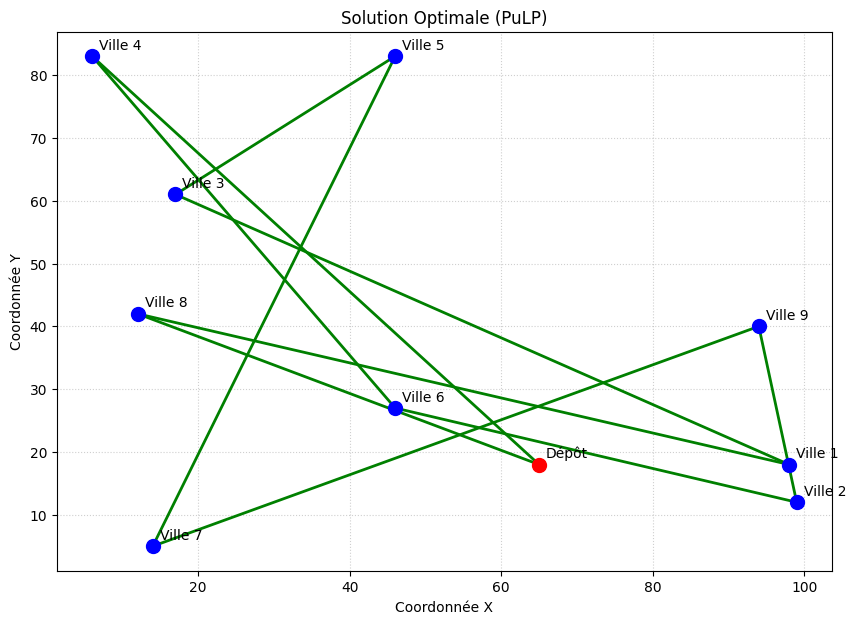

In [ ]:
import matplotlib.pyplot as plt

def afficher_tournee(tournee, instance, titre="Tournée de livraison"):
    coords = instance["coordonnees"]
    matrice = instance["matrice_temps"]
    
    plt.figure(figsize=(10, 7))
    
    # 1. Dessiner les villes
    for i, (x, y) in coords.items():
        color = 'red' if i == 0 else 'blue'
        label = f"Dépôt" if i == 0 else f"Ville {i}"
        plt.scatter(x, y, c=color, s=100, zorder=5)
        plt.annotate(label, (x, y), xytext=(5, 5), textcoords='offset points')

    # 2. Dessiner les trajets
    for k in range(len(tournee) - 1):
        p1 = coords[tournee[k]]
        p2 = coords[tournee[k+1]]
        
        # Si la route est très coûteuse (Contrainte 2), on la dessine en pointillé rouge
        if matrice[tournee[k]][tournee[k+1]] >= 1000:
            plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r--', alpha=0.5)
        else:
            plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'g-', linewidth=2)

    plt.title(titre)
    plt.xlabel("Coordonnée X")
    plt.ylabel("Coordonnée Y")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# Utilisation - on utilise tournee_pulp de la cellule 7
if tournee_pulp:
    afficher_tournee(tournee_pulp, data, titre="Solution Optimale (PuLP)")
else:
    # On affiche au moins la solution du recuit simulé si PuLP n'a pas marché
    afficher_tournee(meilleure_tournee, data, titre="Solution (Recuit Simulé)")